# Notebook 01: EDA

Initial data exploration notebook. Saves an unchanged dataset snapshot for downstream notebooks.

**Notebook run order**

| Step | Notebook | Purpose | Output |
|---|---|---|---|
| 1 | **[01-EDA.ipynb](01-EDA.ipynb)** | **EDA and baseline profiling** | **`data/01-EDA.csv`** |
| 2 | [02-outlier-cleaning.ipynb](02-outlier-cleaning.ipynb) | Outlier strategy evaluation and cleaning | `data/02-outlier-cleaning.csv` |
| 3 | [03-feature-transformations.ipynb](03-feature-transformations.ipynb) | Per-feature transform scans and apply | `data/03-feature-transformations.csv` |
| 4 | [04-interaction-features.ipynb](04-interaction-features.ipynb) | Interaction scans and feature adds | `data/04-interaction-features.csv` |
| 5 | [05-p_censoring.ipynb](05-p_censoring.ipynb) | OOF censoring probability feature | `data/x-final.csv` |

## 1. Notebook set-up

In [1]:
# Standard library imports
import sys
from pathlib import Path

# Third party imports
import pandas as pd
import matplotlib.pyplot as plt

# Use local src package
sys.path.insert(0, str(Path.cwd().resolve().parent / 'src'))
from featurely import plot_feature_distributions, get_feature_correlations, plot_feature_correlations, plot_features_vs_label

from config import DATA_DIR, DATA_URL

## 2. Data loading

**Data source note**: This notebook intentionally loads the raw CSV directly from the original assignment repository:
- Assignment repo: `https://github.com/gperdrizet/fullstack-2605`
- Data file: `https://media.githubusercontent.com/media/gperdrizet/fullstack-2605/refs/heads/main/data/california_housing.csv`

In [2]:
housing_df = pd.read_csv(DATA_URL)
features = [c for c in housing_df.columns if c != 'MedHouseVal']

print(housing_df.info())
housing_df.describe().round(2)

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


## 3. Label distribution

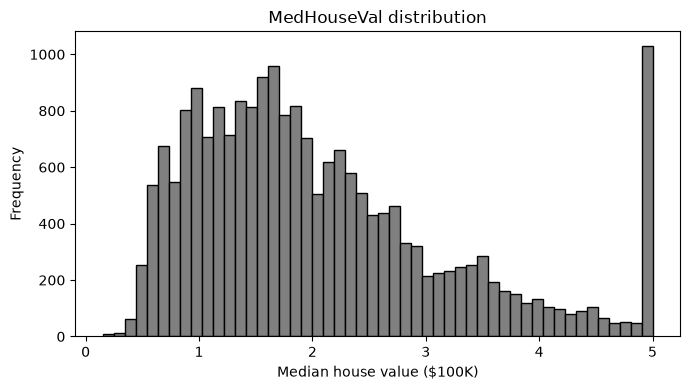

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(housing_df['MedHouseVal'], bins=50, edgecolor='black', color='grey')
ax.set_title('MedHouseVal distribution')
ax.set_xlabel('Median house value ($100K)')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

## 4. Feature distributions

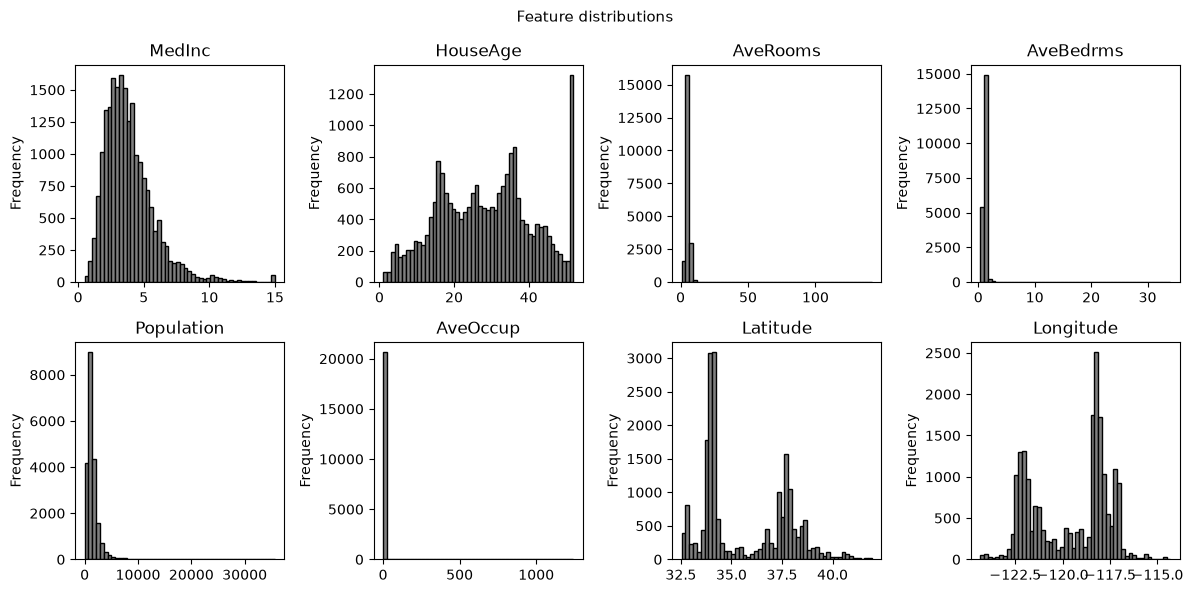

In [4]:
plot_feature_distributions(housing_df)

## 5. Feature correlations

Pearson r      Pearson p  Spearman r     Spearman p
Feature A  Feature B                                                      
AveRooms   AveBedrms    0.847621   0.000000e+00    0.082046   3.616833e-32
MedInc     AveRooms     0.326895   0.000000e+00    0.643671   0.000000e+00
AveRooms   Latitude     0.106389   5.040227e-53    0.127134   4.098513e-75
Population Longitude    0.099773   8.094076e-47    0.123527   5.518247e-71
           AveOccup     0.069863   9.319166e-24    0.242337  1.351588e-273
AveBedrms  Latitude     0.069721   1.146178e-23    0.047197   1.168895e-11
MedInc     AveOccup     0.018766   7.014583e-03   -0.044171   2.171959e-10
AveBedrms  Longitude    0.013344   5.522420e-02    0.010884   1.179095e-01
HouseAge   AveOccup     0.013191   5.807640e-02   -0.024833   3.597526e-04
           Latitude     0.011173   1.084741e-01    0.032440   3.139521e-06
MedInc     Population   0.004834   4.873722e-01    0.006268   3.678980e-01
AveOccup   Longitude    0.002476   7.220875e-01    0.181468  2.643997e-152
           Latitude     0.002366   7.339164e-01   -0.150954  1.833310e-105
AveRooms   AveOccup    -0.004852   4.857571e-01    0.018807   6.892956e-03
AveBedrms  AveOccup    -0.006181   3.745489e-01   -0.132315   2.942673e-81
MedInc     Longitude   -0.015176   2.923867e-02   -0.009928   1.537972e-01
AveRooms   Longitude   -0.027540   7.586900e-05   -0.044783   1.221511e-10
MedInc     AveBedrms   -0.062040   4.615568e-19   -0.252426  1.923590e-297
AveBedrms  Population  -0.066197   1.728435e-21    0.027027   1.030026e-04
AveRooms   Population  -0.072213   2.827077e-25   -0.105385   4.677516e-52
HouseAge   AveBedrms   -0.077747   4.779223e-29   -0.120981   3.822677e-68
MedInc     Latitude    -0.079809   1.596713e-30   -0.088029   8.593935e-37
HouseAge   Longitude   -0.108197   8.637824e-55   -0.150752  3.489000e-105
Population Latitude    -0.108785   2.267532e-55   -0.123626   4.261690e-71
MedInc     HouseAge    -0.119034   5.185138e-66   -0.147308  1.812603e-100
HouseAge   AveRooms    -0.153277  1.032422e-108   -0.231409  5.377523e-249
           Population  -0.296244   0.000000e+00   -0.283879   0.000000e+00
Latitude   Longitude   -0.924664   0.000000e+00   -0.879203   0.000000e+00

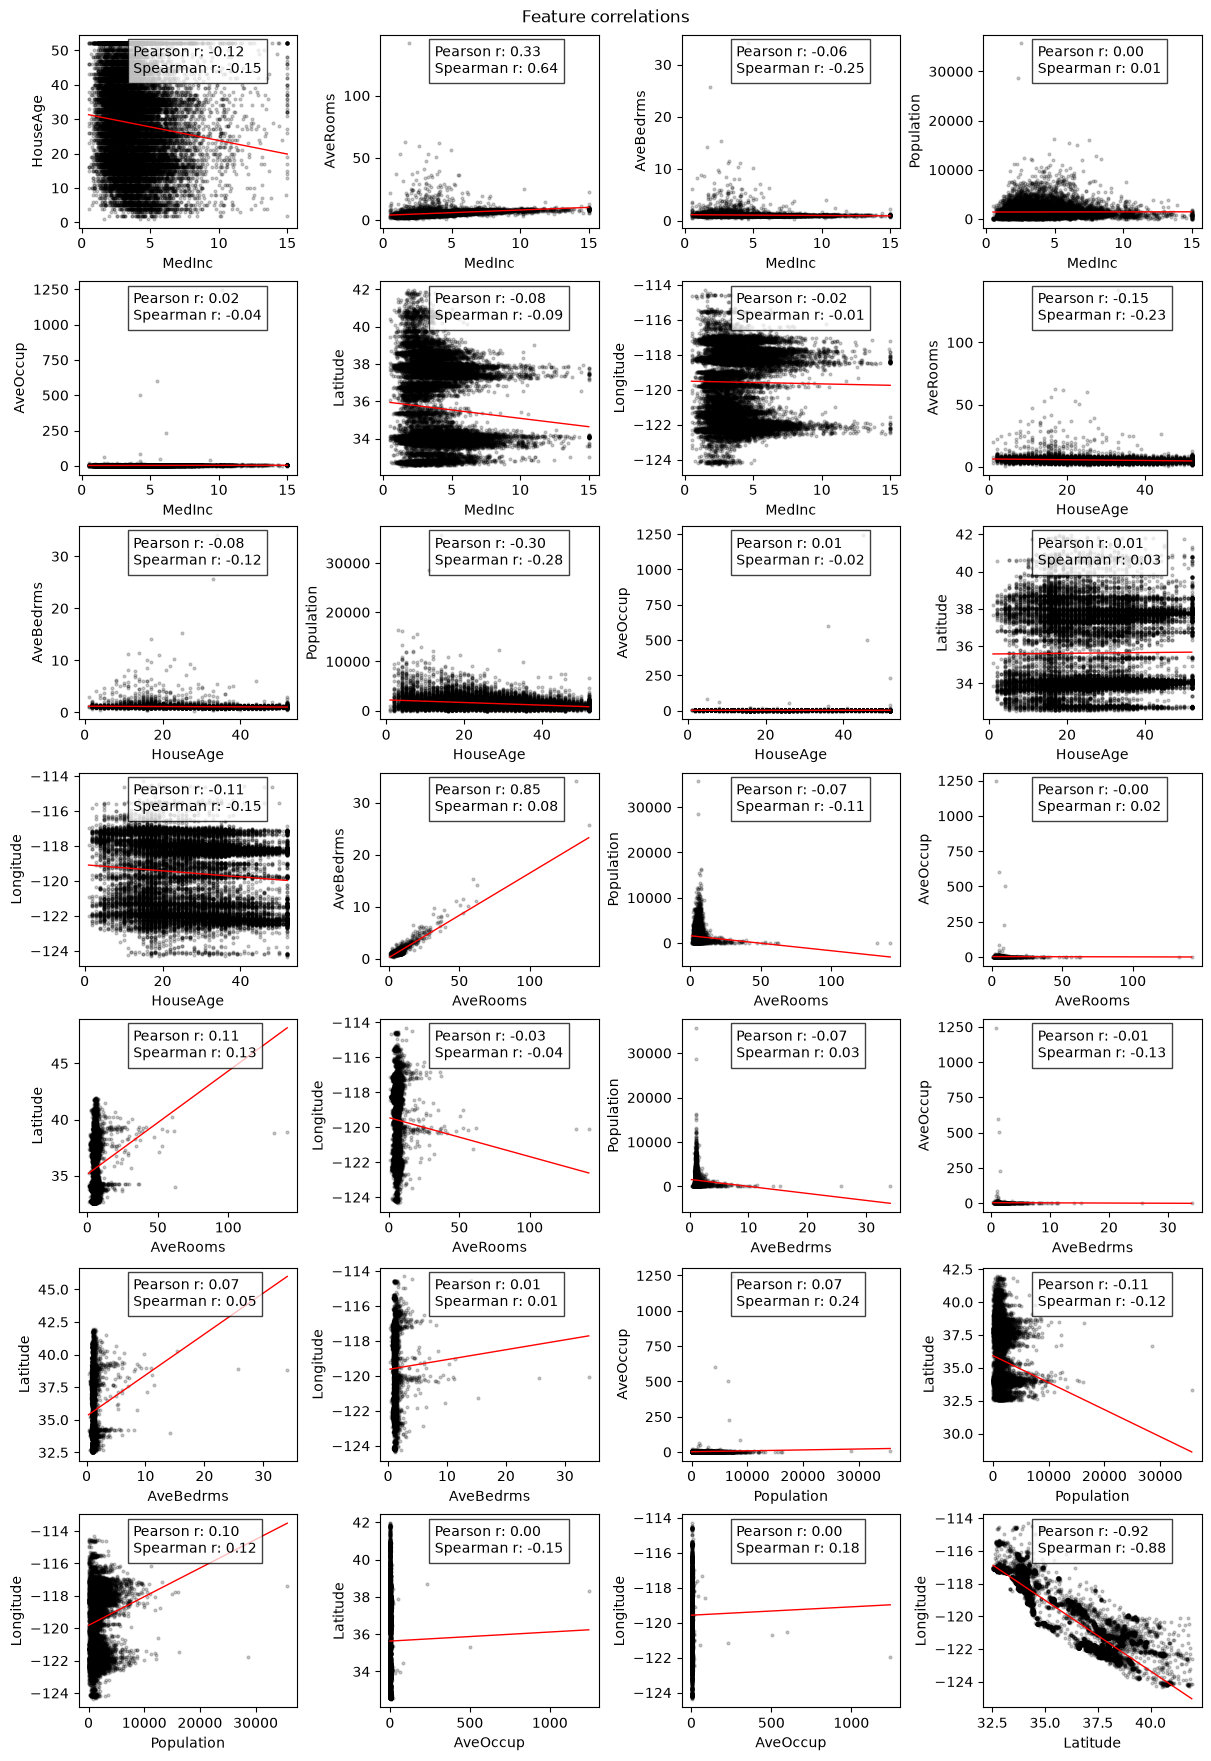

In [5]:
feature_correlations_df = get_feature_correlations(housing_df, features)
display(feature_correlations_df)
plot_feature_correlations(housing_df, features)

## 6. Feature-label correlations

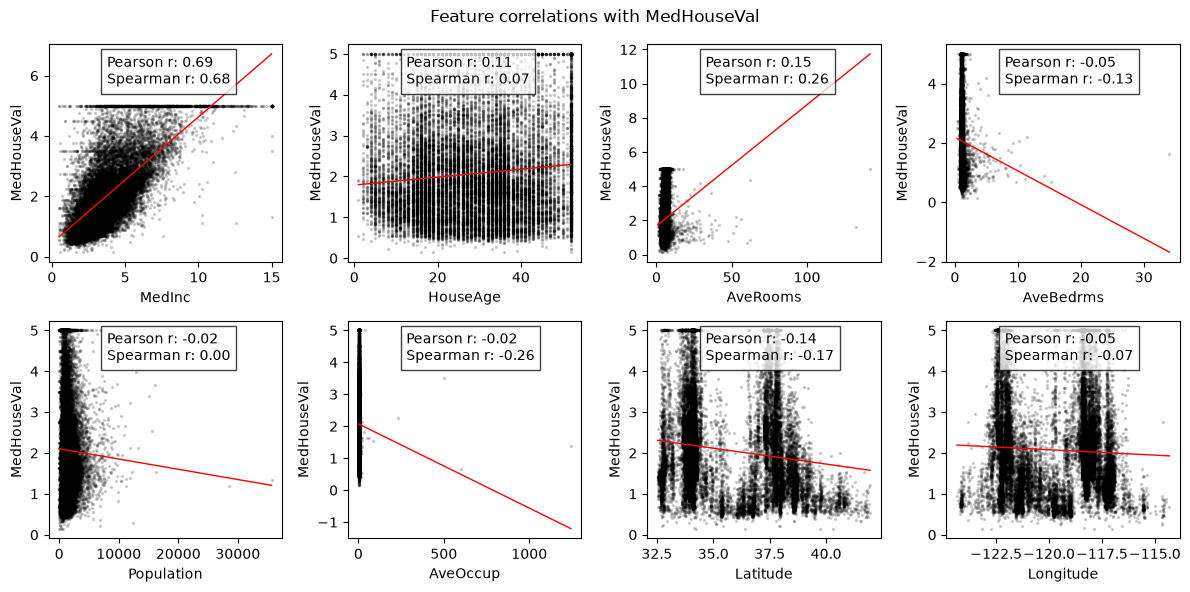

In [6]:
plot_features_vs_label(housing_df, features)

## 7. Save output

In [7]:
out_path = DATA_DIR / '01-EDA.csv'
housing_df.to_csv(out_path, index=False)
print(f'Saved: {out_path}')

Saved: data/01-EDA.csv
